# Object Detection — Evaluation

YOLO11 / Grounding DINO / YOLO-World / OWLv2 の結果を横断比較する。

各実験の `experiment_summary.json` と `best_test_results/` を読み込む。

In [21]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [22]:
CHECKPOINT_ROOT = Path("/workspace/checkpoints/object_detection")

# experiment_name → checkpoint subdir のマッピング
MODEL_RUNS: dict[str, Path] = {
    "yolo11":          CHECKPOINT_ROOT / "yolo11"         / "yolo11_coco",
    "grounding_dino":  CHECKPOINT_ROOT / "grounding_dino" / "grounding_dino_coco",
    "yolo_world":      CHECKPOINT_ROOT / "yolo_world"     / "yolo_world_coco",
    "owlv2":           CHECKPOINT_ROOT / "owlv2"          / "owlv2_coco",
}

In [23]:
def load_json(path: Path) -> dict:
    return json.loads(path.read_text()) if path.exists() else {}

def load_dataframe(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

## 1. Overview — mAP 比較

In [24]:
rows = []
for model_name, run_root in MODEL_RUNS.items():
    summary = load_json(run_root / "experiment_summary.json")
    test_summary = load_json(run_root / "best_test_results" / "summary.json")
    if not summary:
        continue
    rows.append({
        "model":           model_name,
        "experiment_name": summary.get("experiment_name"),
        "mode":            summary.get("mode"),
        "best_source":     summary.get("best_source"),
        "map50":           summary.get("test_map50"),
        "map":             summary.get("test_map"),
        "map_small":       test_summary.get("map_small"),
        "map_medium":      test_summary.get("map_medium"),
        "map_large":       test_summary.get("map_large"),
        "checkpoint":      summary.get("best_checkpoint_path"),
    })

overview_df = pd.DataFrame(rows)
display(overview_df)

,model,experiment_name,mode,best_source,map50,map,map_small,map_medium,map_large,checkpoint
0,yolo11,yolo11_coco,grid,grid,0.469912,0.320189,0.166036,0.354407,0.441633,/workspace/checkpoints/object_detection/yolo11...
1,grounding_dino,grounding_dino_coco,zeroshot,zeroshot,0.650508,0.500012,0.315298,0.532812,0.676430,IDEA-Research/grounding-dino-base
2,yolo_world,yolo_world_coco,zeroshot,zeroshot,0.518350,0.368182,0.205398,0.405177,0.487459,yolov8s-worldv2.pt
3,owlv2,owlv2_coco,zeroshot,zeroshot,0.648978,0.448781,0.309528,0.477187,0.607815,google/owlv2-base-patch16-ensemble


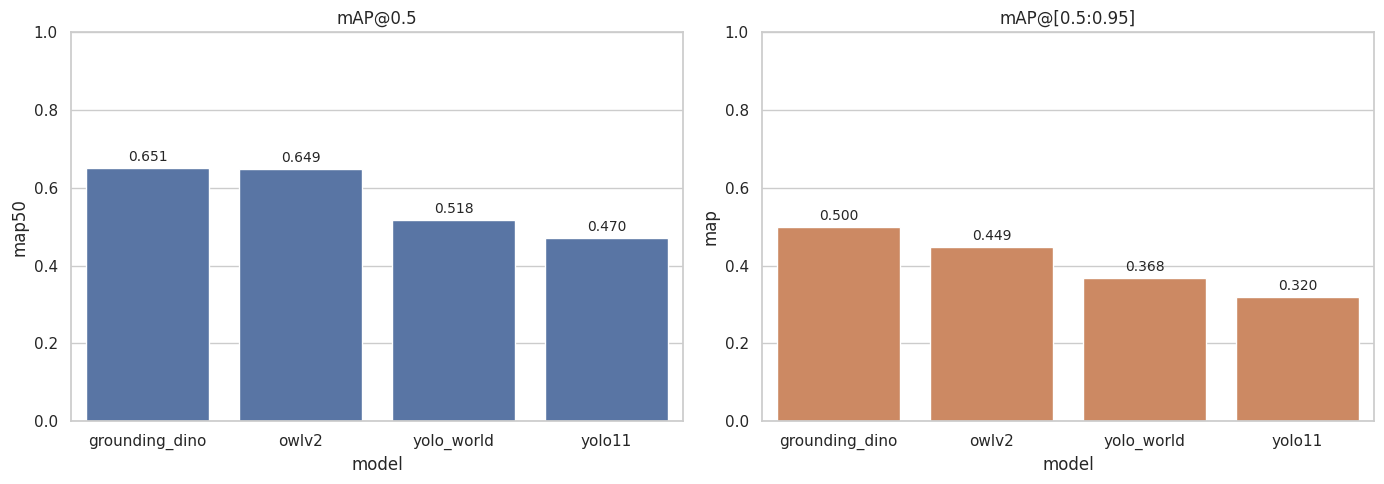

In [25]:
if len(overview_df):
    plot_df = overview_df.dropna(subset=["map50", "map"]).sort_values("map50", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=plot_df, x="model", y="map50", ax=axes[0], color="#4C72B0")
    axes[0].set_title("mAP@0.5")
    axes[0].set_ylim(0, 1)
    for bar in axes[0].patches:
        h = bar.get_height()
        if h == h:
            axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                         f"{h:.3f}", ha="center", va="bottom", fontsize=10)

    sns.barplot(data=plot_df, x="model", y="map", ax=axes[1], color="#DD8452")
    axes[1].set_title("mAP@[0.5:0.95]")
    axes[1].set_ylim(0, 1)
    for bar in axes[1].patches:
        h = bar.get_height()
        if h == h:
            axes[1].text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                         f"{h:.3f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()

## 2. Scale 別 mAP (small / medium / large)

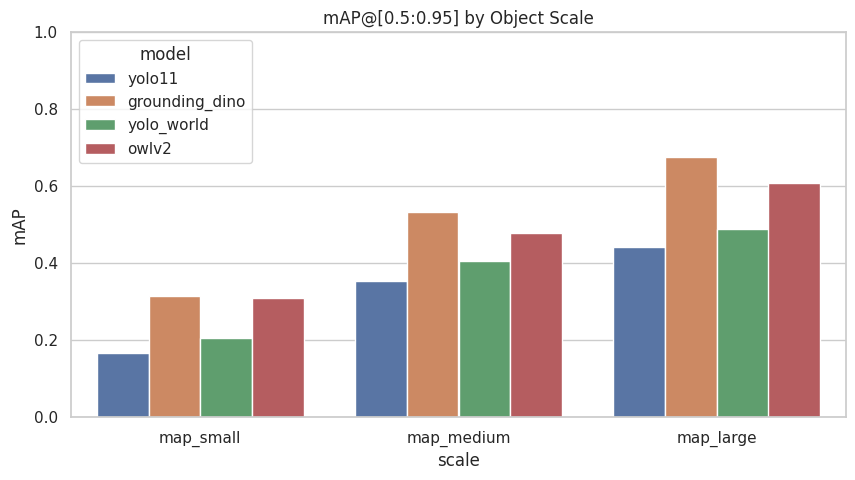

In [26]:
scale_cols = ["model", "map_small", "map_medium", "map_large"]
scale_df = overview_df[scale_cols].dropna()

if len(scale_df):
    melted = scale_df.melt(id_vars="model", var_name="scale", value_name="mAP")
    plt.figure(figsize=(10, 5))
    sns.barplot(data=melted, x="scale", y="mAP", hue="model")
    plt.title("mAP@[0.5:0.95] by Object Scale")
    plt.ylim(0, 1)
    plt.show()
else:
    print("No scale data available yet.")

## 3. Per-category AP

In [27]:
cat_frames = []
for model_name, run_root in MODEL_RUNS.items():
    df = load_dataframe(run_root / "best_test_results" / "per_category_ap.csv")
    if len(df):
        df["model"] = model_name
        cat_frames.append(df)

cat_df = pd.concat(cat_frames, ignore_index=True) if cat_frames else pd.DataFrame()
display(cat_df.head(20) if len(cat_df) else "No per-category data yet.")

,category_id,name,ap,ap50,model
0,1,person,0.501571,0.764076,yolo11
1,2,bicycle,0.234891,0.427574,yolo11
2,3,car,0.352664,0.569381,yolo11
3,4,motorcycle,0.351333,0.610074,yolo11
4,5,airplane,0.567296,0.751953,yolo11
5,6,bus,0.562052,0.693057,yolo11
6,7,train,0.573665,0.745797,yolo11
7,8,truck,0.219688,0.333988,yolo11
8,9,boat,0.176135,0.358964,yolo11
9,10,traffic light,0.204365,0.417682,yolo11


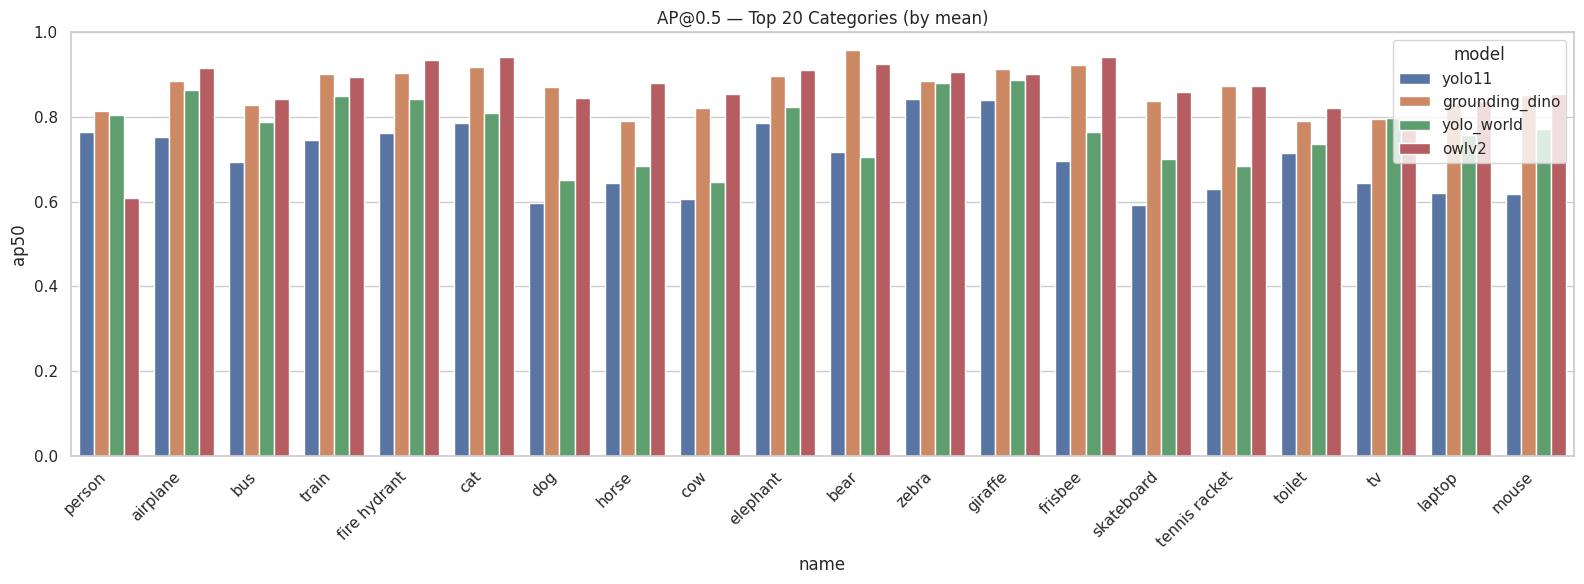

In [28]:
# 上位 20 カテゴリの AP@0.5 比較
if len(cat_df):
    top_cats = (
        cat_df.groupby("name")["ap50"].mean()
        .sort_values(ascending=False)
        .head(20)
        .index.tolist()
    )
    plot_cat_df = cat_df[cat_df["name"].isin(top_cats)]

    plt.figure(figsize=(16, 6))
    sns.barplot(data=plot_cat_df, x="name", y="ap50", hue="model")
    plt.title("AP@0.5 — Top 20 Categories (by mean)")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

## 4. YOLO11 Grid Tuning 結果

In [29]:
grid_csv = MODEL_RUNS["yolo11"] / "grid" / "tuning_results.csv"
grid_df = load_dataframe(grid_csv)

if len(grid_df):
    display(grid_df.sort_values("best_valid_map50", ascending=False))
else:
    print("Grid tuning not run yet.")

Grid tuning not run yet.


## 5. Supervised vs Zero-shot — まとめ

In [30]:
if len(overview_df):
    display(
        overview_df[["model", "mode", "map50", "map"]]
        .sort_values("map50", ascending=False)
        .reset_index(drop=True)
    )

,model,mode,map50,map
0,grounding_dino,zeroshot,0.650508,0.500012
1,owlv2,zeroshot,0.648978,0.448781
2,yolo_world,zeroshot,0.518350,0.368182
3,yolo11,grid,0.469912,0.320189


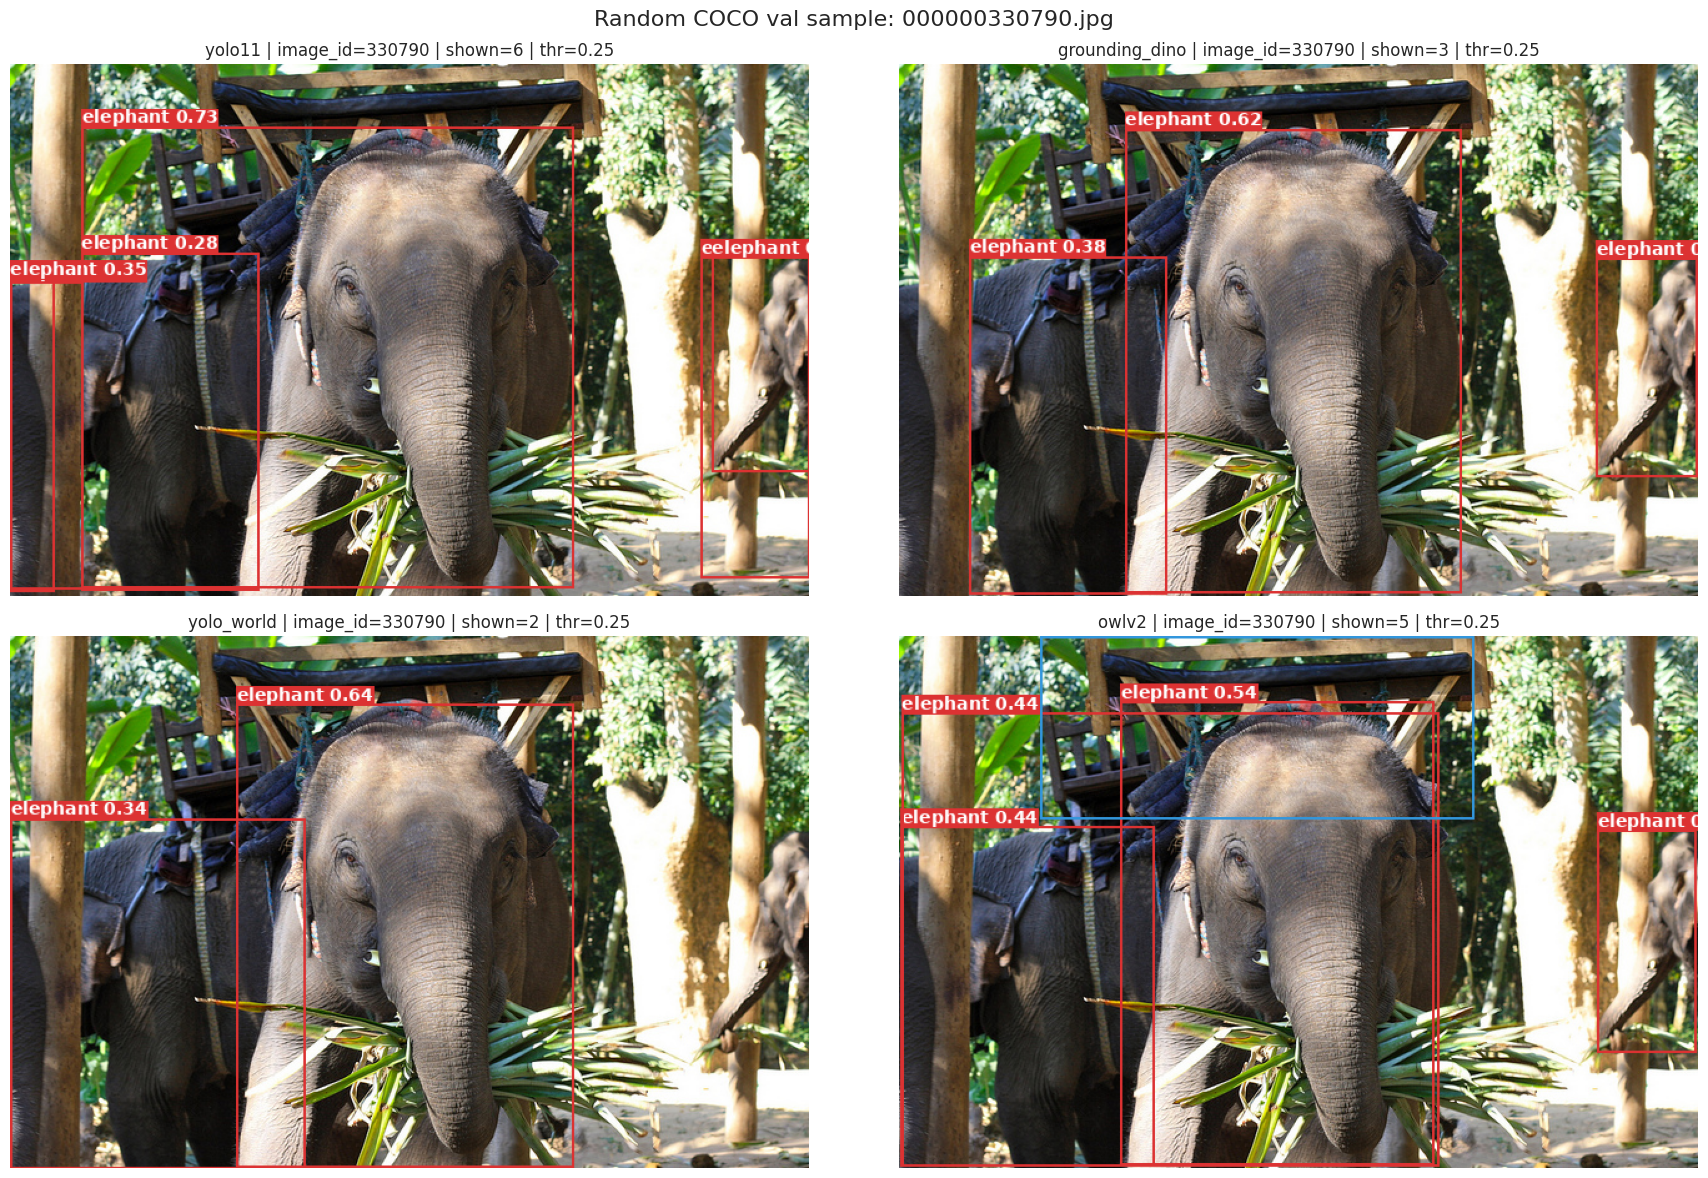

In [34]:
# 6. Random sample visualization — test image predictions by model
import random

from PIL import Image

from src.object_detection.common.visualization import draw_detections

VAL_ANN_PATH = Path("/workspace/data/coco/annotations/instances_val2017.json")
VAL_IMAGE_ROOT = Path("/workspace/data/coco/val2017")
VIS_SCORE_THRESHOLDS = {
    "yolo11": 0.25,
    "grounding_dino": 0.25,
    "yolo_world": 0.25,
    "owlv2": 0.25,
}

ann = load_json(VAL_ANN_PATH)
image_info_by_id = {img["id"]: img for img in ann.get("images", [])}
category_name_by_id = {cat["id"]: cat["name"] for cat in ann.get("categories", [])}

prediction_frames = {}
candidate_image_ids = set()
for model_name, run_root in MODEL_RUNS.items():
    pred_path = run_root / "best_test_results" / "predictions.json"
    preds = load_json(pred_path)
    df = pd.DataFrame(preds) if preds else pd.DataFrame(columns=["image_id", "category_id", "bbox", "score"])
    prediction_frames[model_name] = df
    if len(df):
        candidate_image_ids.update(df["image_id"].unique().tolist())

if not candidate_image_ids:
    print("No predictions found for visualization.")
else:
    selected_image_id = random.choice(sorted(candidate_image_ids))
    image_info = image_info_by_id[selected_image_id]
    image_path = VAL_IMAGE_ROOT / image_info["file_name"]
    base_image = Image.open(image_path).convert("RGB")

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()

    for ax, model_name in zip(axes, MODEL_RUNS):
        pred_df = prediction_frames[model_name]
        if len(pred_df):
            pred_df = pred_df[pred_df["image_id"] == selected_image_id].sort_values("score", ascending=False)
        threshold = VIS_SCORE_THRESHOLDS.get(model_name, 0.25)

        if len(pred_df):
            boxes = pred_df["bbox"].tolist()
            labels = [category_name_by_id.get(int(cat_id), str(cat_id)) for cat_id in pred_df["category_id"].tolist()]
            scores = pred_df["score"].astype(float).tolist()
            vis_image = draw_detections(
                base_image,
                boxes=boxes,
                labels=labels,
                scores=scores,
                score_threshold=threshold,
                box_format="xywh",
            )
            shown_count = int((pred_df["score"].astype(float) >= threshold).sum())
        else:
            vis_image = base_image.copy()
            shown_count = 0

        ax.imshow(vis_image)
        ax.set_title(f"{model_name} | image_id={selected_image_id} | shown={shown_count} | thr={threshold:.2f}")
        ax.axis("off")

    plt.suptitle(f"Random COCO val sample: {image_info['file_name']}", fontsize=16)
    plt.tight_layout()
    plt.show()


In [35]:
# 7. Detection axes — existence vs classification (approximate, IoU@0.5)
from collections import defaultdict

MATCH_IOU_THRESHOLD = 0.5
AXIS_SCORE_THRESHOLDS = {
    "yolo11": 0.25,
    "grounding_dino": 0.25,
    "yolo_world": 0.25,
    "owlv2": 0.25,
}

ann = load_json(Path("/workspace/data/coco/annotations/instances_val2017.json"))
gt_by_image = defaultdict(list)
for obj in ann.get("annotations", []):
    if obj.get("iscrowd", 0):
        continue
    gt_by_image[int(obj["image_id"])].append({
        "bbox": obj["bbox"],
        "category_id": int(obj["category_id"]),
    })

def iou_xywh(box_a, box_b) -> float:
    ax1, ay1, aw, ah = [float(x) for x in box_a]
    bx1, by1, bw, bh = [float(x) for x in box_b]
    ax2, ay2 = ax1 + aw, ay1 + ah
    bx2, by2 = bx1 + bw, by1 + bh

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    union_area = aw * ah + bw * bh - inter_area
    return inter_area / union_area if union_area > 0 else 0.0

def evaluate_detection_axes(pred_df: pd.DataFrame, score_threshold: float, iou_threshold: float) -> dict:
    preds_by_image = defaultdict(list)
    if len(pred_df):
        filtered = pred_df[pred_df["score"].astype(float) >= score_threshold]
        for row in filtered.itertuples(index=False):
            preds_by_image[int(row.image_id)].append({
                "bbox": row.bbox,
                "category_id": int(row.category_id),
                "score": float(row.score),
            })

    total_gt = sum(len(items) for items in gt_by_image.values())
    total_preds = sum(len(items) for items in preds_by_image.values())
    matched_gt_any = 0
    matched_gt_correct_class = 0

    for image_id, gt_items in gt_by_image.items():
        pred_items = sorted(preds_by_image.get(image_id, []), key=lambda x: x["score"], reverse=True)
        used_gt_indices = set()

        for pred in pred_items:
            best_gt_idx = None
            best_iou = 0.0
            for gt_idx, gt in enumerate(gt_items):
                if gt_idx in used_gt_indices:
                    continue
                iou = iou_xywh(pred["bbox"], gt["bbox"])
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx

            if best_gt_idx is not None and best_iou >= iou_threshold:
                used_gt_indices.add(best_gt_idx)
                matched_gt_any += 1
                if pred["category_id"] == gt_items[best_gt_idx]["category_id"]:
                    matched_gt_correct_class += 1

    existence_recall = matched_gt_any / total_gt if total_gt else float("nan")
    existence_precision = matched_gt_any / total_preds if total_preds else float("nan")
    classification_accuracy_on_matched = (
        matched_gt_correct_class / matched_gt_any if matched_gt_any else float("nan")
    )
    class_and_localization_recall = (
        matched_gt_correct_class / total_gt if total_gt else float("nan")
    )

    return {
        "gt_objects": total_gt,
        "predictions_after_threshold": total_preds,
        "existence_recall_iou50": existence_recall,
        "existence_precision_iou50": existence_precision,
        "classification_accuracy_on_matched": classification_accuracy_on_matched,
        "class_and_localization_recall_iou50": class_and_localization_recall,
    }

axis_rows = []
for model_name, run_root in MODEL_RUNS.items():
    pred_path = run_root / "best_test_results" / "predictions.json"
    preds = load_json(pred_path)
    pred_df = pd.DataFrame(preds) if preds else pd.DataFrame(columns=["image_id", "category_id", "bbox", "score"])
    metrics = evaluate_detection_axes(
        pred_df,
        score_threshold=AXIS_SCORE_THRESHOLDS.get(model_name, 0.25),
        iou_threshold=MATCH_IOU_THRESHOLD,
    )
    metrics["model"] = model_name
    metrics["score_threshold"] = AXIS_SCORE_THRESHOLDS.get(model_name, 0.25)
    axis_rows.append(metrics)

axis_df = pd.DataFrame(axis_rows)[[
    "model",
    "score_threshold",
    "gt_objects",
    "predictions_after_threshold",
    "existence_recall_iou50",
    "existence_precision_iou50",
    "classification_accuracy_on_matched",
    "class_and_localization_recall_iou50",
]]
display(axis_df.sort_values("existence_recall_iou50", ascending=False).reset_index(drop=True))

print("Notes:")
print("- existence_* はクラスを無視して IoU>=0.5 で何かを当てられたかを見る近似指標")
print("- classification_accuracy_on_matched は、位置が合った予測のうちクラスも正しい割合")
print("- class_and_localization_recall_iou50 は、GT 全体に対して位置もクラスも正しかった割合")


,model,score_threshold,gt_objects,predictions_after_threshold,existence_recall_iou50,existence_precision_iou50,classification_accuracy_on_matched,class_and_localization_recall_iou50
0,grounding_dino,0.25,36335,41507,0.745204,0.652348,0.972818,0.724948
1,yolo_world,0.25,36335,31121,0.565130,0.659812,0.933330,0.527453
2,yolo11,0.25,36335,23444,0.477116,0.739464,0.938971,0.447998
3,owlv2,0.25,36335,32659,0.446567,0.496831,0.942315,0.420806


Notes:
- existence_* はクラスを無視して IoU>=0.5 で何かを当てられたかを見る近似指標
- classification_accuracy_on_matched は、位置が合った予測のうちクラスも正しい割合
- class_and_localization_recall_iou50 は、GT 全体に対して位置もクラスも正しかった割合
